In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.interpolate import interp1d

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
wise = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/w1_bright-2mass-13.3-dr9.fits'))
print(len(wise))

wise['w1ab'] = np.array(wise['W1MPRO']) + 2.699

w1_mags = [0, 0.5, 1, 2, 2.5, 4.0, 5.0, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0]
w1_radii = [600, 600, 500, 425, 375, 350, 350, 300, 250, 200, 175, 150, 100, 100]
w1_max_mag = 9.0

f_radius = interp1d(w1_mags, w1_radii, bounds_error=False, fill_value='extrapolate')
wise['radius'] = f_radius(wise['w1ab'])

10063086


In [4]:
mask = wise['w1ab']<13
wise = wise[mask]
print(len(wise))

1030815


In [5]:
gaia_columns = ['RA', 'DEC', 'PHOT_G_MEAN_MAG', 'PHOT_BP_MEAN_MAG', 'PHOT_RP_MEAN_MAG']
gaia_path = '/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_18_dr9.fits'
gaia = Table(fitsio.read(gaia_path, columns=gaia_columns))
print(len(gaia))

gaia['radius'] = 1630 * 1.396**(-gaia['PHOT_G_MEAN_MAG'])

41052993


In [6]:
mask = gaia['PHOT_G_MEAN_MAG']<12
gaia = gaia[mask]
print(len(gaia))

919016


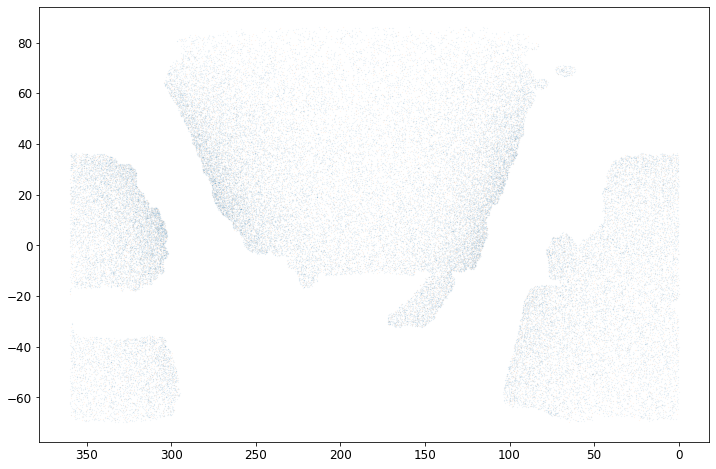

In [7]:
plt.figure(figsize=(12, 8))
plt.plot(wise['RA'][::20], wise['DEC'][::20], '.', ms=0.1, alpha=0.5)
plt.plot(gaia['RA'][::100], gaia['DEC'][::100], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [8]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(gaia['RA'], gaia['DEC'], wise['RA'], wise['DEC'], search_radius=1., plot_q=False)

Doubly matched objects = 0
Final matched objects = 768827


In [9]:
print(len(idx1)/len(gaia))
print(len(idx1)/len(wise))

0.8365762946455775
0.7458438226063843


In [10]:
gaia = gaia[idx1]
wise = wise[idx2]

0.7700144195556641


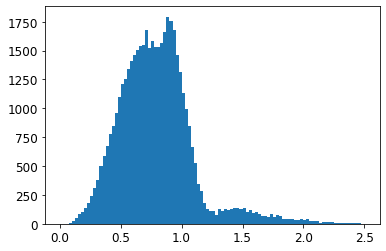

In [27]:
mask = wise['w1ab']<w1_max_mag
plt.hist((gaia['radius']/wise['radius'])[mask], 100, range=(0, 2.5));
print(np.median((gaia['radius']/wise['radius'])[mask]))

0.7700144195556641


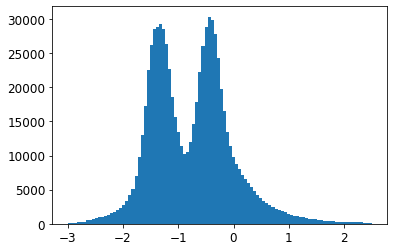

In [32]:
plt.hist(gaia['PHOT_G_MEAN_MAG']-wise['w1ab'], 100, range=(-3, 2.5));
print(np.median((gaia['radius']/wise['radius'])[mask]))

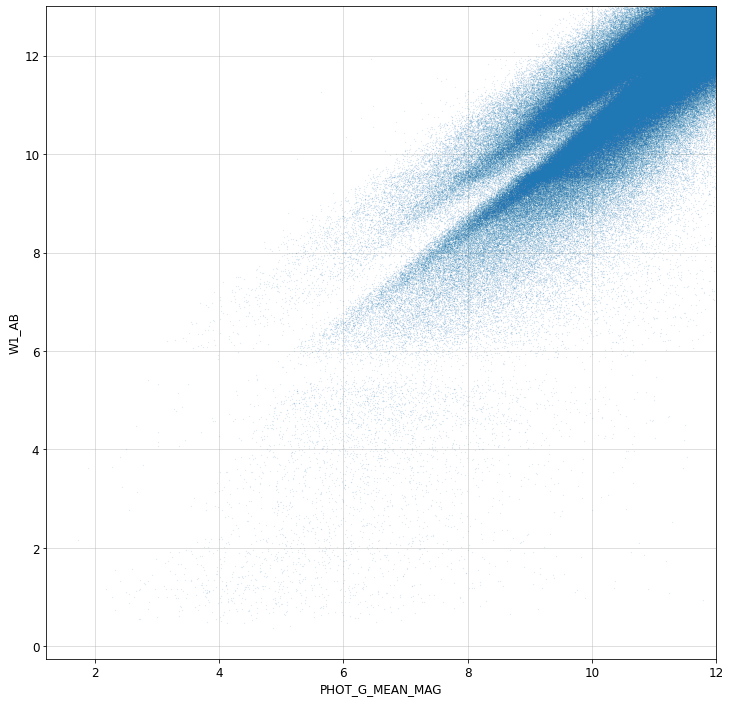

In [11]:
plt.figure(figsize=(12, 12))
plt.plot(gaia['PHOT_G_MEAN_MAG'], wise['w1ab'], '.', ms=0.1, alpha=1)
plt.xlabel('PHOT_G_MEAN_MAG')
plt.ylabel('W1_AB')
plt.grid(alpha=0.5)
plt.xlim(xmax=12)
plt.ylim(ymax=13)
plt.show()

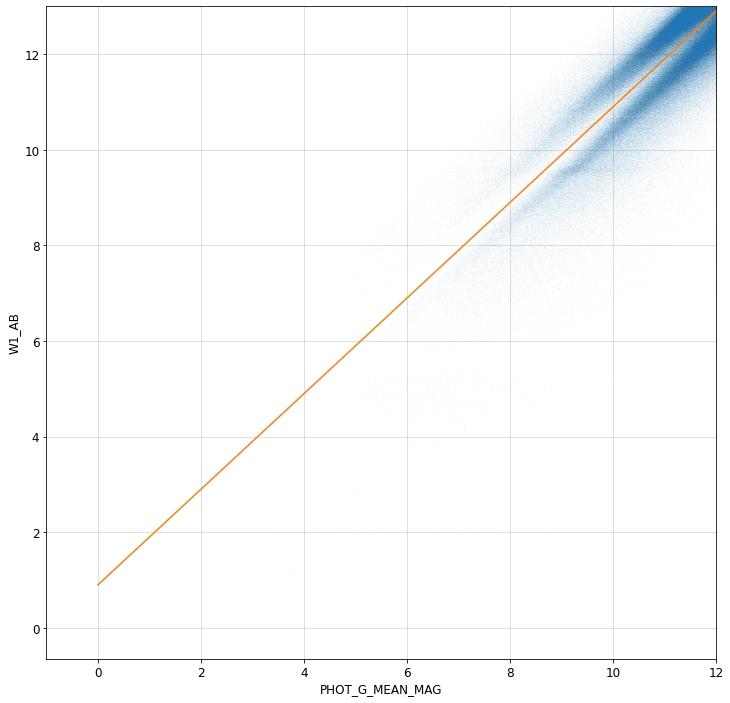

In [12]:
x = np.linspace(0, 20)

plt.figure(figsize=(12, 12))
plt.plot(gaia['PHOT_G_MEAN_MAG'], wise['w1ab'], '.', ms=0.1, alpha=0.1)
plt.plot(x, x+0.9)
plt.xlabel('PHOT_G_MEAN_MAG')
plt.ylabel('W1_AB')
plt.grid(alpha=0.5)
plt.xlim(xmax=12)
plt.ylim(ymax=13)
plt.show()

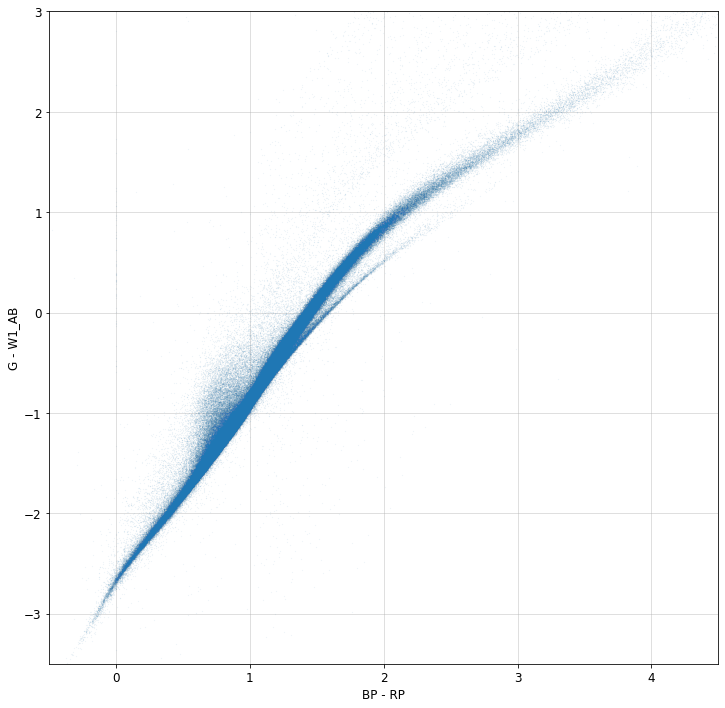

In [13]:
plt.figure(figsize=(12, 12))
plt.plot((gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG']), (gaia['PHOT_G_MEAN_MAG']-wise['w1ab']), '.', ms=0.1, alpha=0.5)
plt.xlabel('BP - RP')
plt.ylabel('G - W1_AB')
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -3.5, 3.])
plt.show()

In [14]:
mask1 = (wise['w1ab'] > gaia['PHOT_G_MEAN_MAG'] + 0.9)
mask2 = (wise['w1ab'] <= gaia['PHOT_G_MEAN_MAG'] + 0.9)

In [28]:
mask1 &= gaia['PHOT_G_MEAN_MAG']<8
mask2 &= gaia['PHOT_G_MEAN_MAG']<8

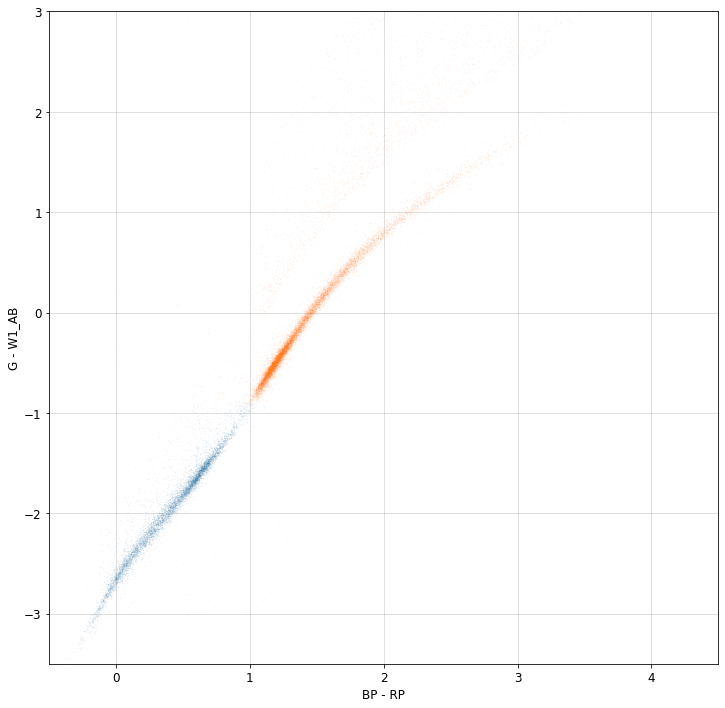

In [29]:
plt.figure(figsize=(12, 12))
plt.plot((gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG'])[mask1], (gaia['PHOT_G_MEAN_MAG']-wise['w1ab'])[mask1], '.', ms=0.1, alpha=0.5)
plt.plot((gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG'])[mask2], (gaia['PHOT_G_MEAN_MAG']-wise['w1ab'])[mask2], '.', ms=0.1, alpha=0.5)
plt.xlabel('BP - RP')
plt.ylabel('G - W1_AB')
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -3.5, 3.])
plt.show()

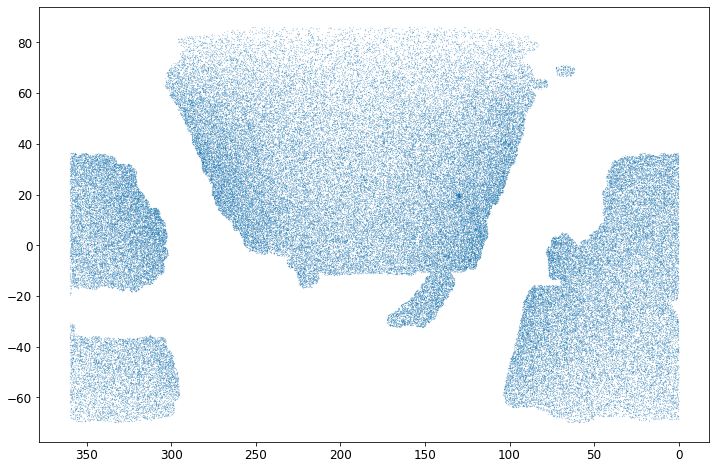

In [98]:
plt.figure(figsize=(12, 8))
plt.plot(wise['RA'][mask1], wise['DEC'][mask1], '.', ms=0.2, alpha=1)
plt.gca().invert_xaxis()
plt.show()

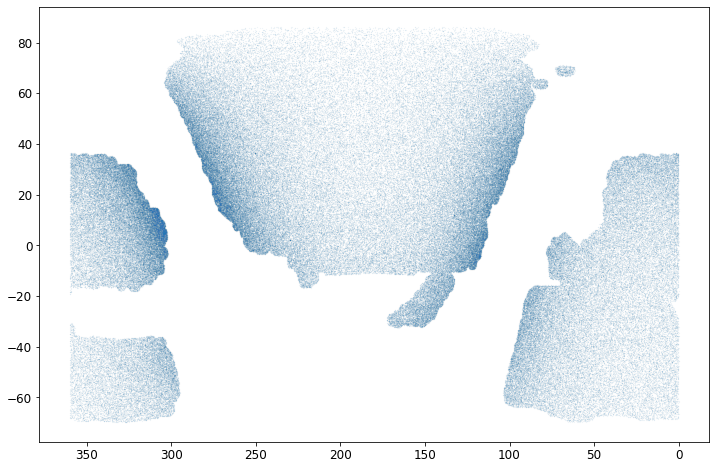

In [99]:
plt.figure(figsize=(12, 8))
plt.plot(wise['RA'][mask2], wise['DEC'][mask2], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [89]:
mask = (wise['w1ab'] > gaia['PHOT_G_MEAN_MAG'] + 0.9) & (wise['w1ab']<12)

idx = np.where(mask)[0]
idx = np.random.choice(idx, size=len(idx), replace=False)
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
else:
    idx = np.random.choice(idx, size=len(idx), replace=False)
t = Table()
t['RA'] = wise['RA'][idx]
t['DEC'] = wise['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection_wise.txt', format='ascii.no_header', overwrite=True)

126524


In [90]:
mask = (wise['w1ab'] <= gaia['PHOT_G_MEAN_MAG'] + 0.9) & (wise['w1ab']<12)

idx = np.where(mask)[0]
idx = np.random.choice(idx, size=len(idx), replace=False)
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
else:
    idx = np.random.choice(idx, size=len(idx), replace=False)
t = Table()
t['RA'] = wise['RA'][idx]
t['DEC'] = wise['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection_wise1.txt', format='ascii.no_header', overwrite=True)

324602
